# Modeling

In [142]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df_clean = pd.read_csv('breast_cancer_preprocessed.csv')
df_clean.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,area_perimeter_ratio,radius_growth_ratio,concavity_score,RadiusCategory,diagnosis
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,2.616665,2.109526,2.296076,2.750622,1.937015,0.894884,3.310149,2.659906,0.203921,1
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.430444,-0.146749,1.087084,-0.243890,0.281190,2.018656,0.897126,0.166321,1.710816,1
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.082932,0.854974,1.955000,1.152255,0.201391,1.573335,0.677613,1.612210,1.710816,1
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,3.893397,1.989588,2.175786,6.046041,4.935010,-1.058938,2.014637,1.795277,-1.302974,1
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1.786555,-0.383659,1.414531,1.710816,1


## Data Splitting

In [114]:
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, 
  stratify=y,
  train_size=0.2,
  random_state=42
)

In [116]:
def evaluate_model(name, y_true, y_pred):
  print(f"--- Evaluasi Model: {name} ---")
  # 1. Balanced Accuracy
  b_acc = balanced_accuracy_score(y_true, y_pred)
  print(f"Balanced Accuracy: {b_acc:.4f}\n")
  # 2. Classification Report
  print("Classification Report:")
  print(classification_report(y_true, y_pred, target_names=['Malignant', 'Benign']))
  # 3. Confusion Matrix Visualization
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(4,3))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Confusion Matrix: {name}')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

### Logistic Regression (Baseline)

In [117]:
lr_model = LogisticRegression(
  random_state=42,
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

--- Evaluasi Model: LogisticRegression ---
Balanced Accuracy: 0.9706

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.97      1.00      0.98       286
      Benign       1.00      0.94      0.97       170

    accuracy                           0.98       456
   macro avg       0.98      0.97      0.98       456
weighted avg       0.98      0.98      0.98       456



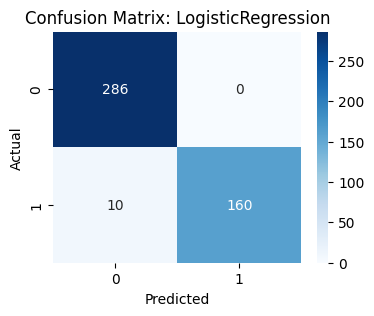

In [118]:
evaluate_model('LogisticRegression', y_test, y_pred_lr)

### K-Nearest Neighbors

In [ ]:
param_dist = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'knn__p': [1, 2]  # 1=manhattan, 2=euclidean (for minkowski)
}

knn = KNeighborsClassifier(n_jobs=-1)

random_search_knn = RandomizedSearchCV(
  knn,
  param_distributions=param_dist,
  n_iter=30,
  cv=3,
  verbose=2,
  random_state=42,
  n_jobs=-1
)

random_search_knn.fit(X_train, y_train)

evaluate_model(
    y_test,
    random_search_knn.predict(X_test)
)

In [119]:
knn_model = KNeighborsClassifier(
  n_neighbors=5,
  weights='distance', 
  metric='euclidean'
)

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

--- Evaluasi Model: kNN ---
Balanced Accuracy: 0.9247

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.92      1.00      0.96       286
      Benign       0.99      0.85      0.92       170

    accuracy                           0.94       456
   macro avg       0.96      0.92      0.94       456
weighted avg       0.95      0.94      0.94       456



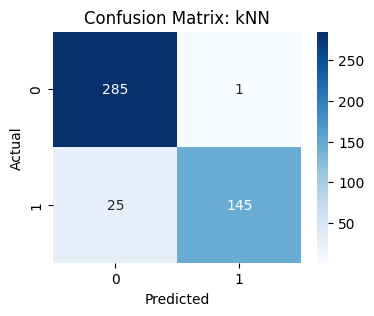

In [120]:
evaluate_model('kNN', y_test, y_pred_knn)

### Random Forest

In [ ]:
# hyperparameter tuning using RandomizedSearchCV
param_dist = {
  'bootstrap': [True, False],
  'max_depth': [10, 30, 50, None],
  'max_features': ['sqrt', 'log2'],
  'min_samples_leaf': [1, 2, 4],
  'min_samples_split': [2, 5, 10],
  'n_estimators': [200, 500, 1000]
}

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

random_search = RandomizedSearchCV(
  rf,
  param_distributions=param_dist,
  n_iter=50,         
  cv=3,
  verbose=2,
  random_state=42,
  n_jobs=-1
)

random_search.fit(X_train, y_train)

evaluate_model(
  y_test,
  random_search.predict(X_test)
)

In [140]:
rf_model = RandomForestClassifier(
  n_estimators=200,
  bootstrap=True,
  max_features="sqrt", 
  max_depth=10, 
  max_leaf_nodes=6,
  min_samples_split=2,
  random_state=42,
  n_jobs=-1
  
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

--- Evaluasi Model: RandomForest ---
Balanced Accuracy: 0.9430

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.94      0.99      0.96       286
      Benign       0.97      0.90      0.94       170

    accuracy                           0.95       456
   macro avg       0.96      0.94      0.95       456
weighted avg       0.95      0.95      0.95       456



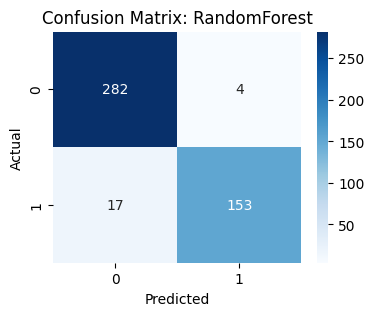

In [146]:
evaluate_model('RandomForest', y_test, y_pred_rf)